## HW 2/1: Smart up and customize plotter

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams  # detailed parameter setting

""" more details on customization: https://matplotlib.org/stable/tutorials/introductory/customizing.html """
from typing import Dict, List, Union


# some type hints in the header of the function
def my_plotter(x: List[float], y: Union[List[float], List[List[float]]], layout: Dict = None,
                     names: List[str] = None, colors: List[str] = None) -> None:
    if layout is None:
        layout = {}

    default_layout = {
        'figsize': (10, 6),
        'line_style': '-',
        'linewidth': 4,
        'legend_fontsize': 10,
        'title_fontsize': 20,
        'titlepad': 30,
        'label_fontsize': 16,
        'labelpad': 20,
        'hline_style': '--',
        'hline_color': 'black',
        'hline_width': 1,
        'style': 'ggplot'
    }
    default_layout.update(layout)
    layout = default_layout

    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y

    fig, ax = plt.subplots(figsize=layout['figsize'])
    lines = []
    show_legend = True if names is not None else False

    plot_kwargs = {
        'linestyle': layout['line_style'],
        'linewidth': layout['linewidth'],
    }

    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    for i, y_item in enumerate(y):
        if show_legend:
            plot_kwargs['label'] = names[i]
        _plot_line = plt.plot(x, y_item, **plot_kwargs)
        lines.append(_plot_line)

    if 'title' in layout:
        ax.set_title(layout['title'], fontsize=layout['title_fontsize'])
        rcParams['axes.titlepad'] = layout['titlepad']
    if 'x_label' in layout:
        ax.set_xlabel(layout['x_label'], fontsize=layout['label_fontsize'])
        rcParams['axes.labelpad'] = layout['labelpad']
    if 'y_label' in layout:
        ax.set_ylabel(layout['y_label'], fontsize=layout['label_fontsize'])
        rcParams['axes.labelpad'] = layout['labelpad']
    if show_legend:
        ax.legend(fontsize=layout['legend_fontsize'])

    ax.axhline(linestyle=layout['hline_style'], color=layout['hline_color'], linewidth=layout['hline_width'])

    plt.style.use(layout['style'])
    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
strike = 100
step_size = 0.01

x_stock_price = np.arange(0, 2 * strike, step_size)
y_forward_payoff = np.array([x - strike for x in x_stock_price])

y_forward_payoff__short = y_forward_payoff * (-1)

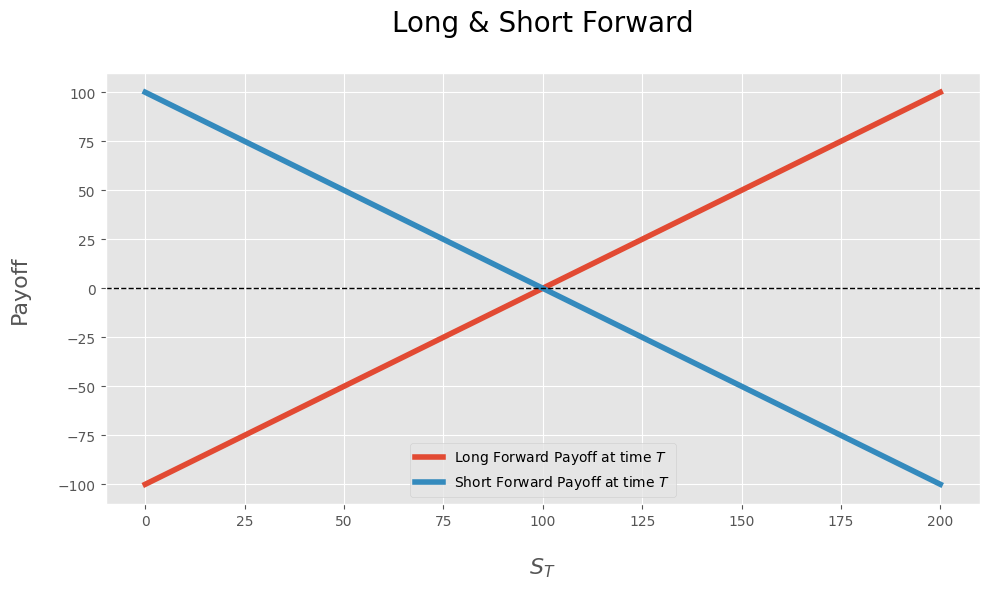

In [4]:
layout = {'title': 'Long & Short Forward',
          'x_label': '$S_{T}$',
          'y_label': 'Payoff',
}
my_plotter(x_stock_price, [y_forward_payoff, y_forward_payoff__short], layout=layout,
                 names=['Long Forward Payoff at time $T$',
                        'Short Forward Payoff at time $T$'])

## HW 2/2: BSM pricer with Greeks

In [5]:
import numpy as np
from scipy.stats import norm

"""The pricing function of European call option"""
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray],
                           output: str = 'price') -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0
    assert T > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    derN_d1 = norm.pdf(d1_vec)

    output = output.lower()
    if output == 'price':
        return N_d1_vec * S0 - K * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'delta':
        return N_d1_vec
    elif output == 'gamma':
        return derN_d1 / (S0 * sigma * T**0.5)
    elif output == 'vega':
        return S0 * derN_d1 * T**0.5
    elif output == 'theta':
        return (-S0 * derN_d1 * sigma / (2 * T**0.5)) - (r * K * np.exp((-1.0)*r*T) * N_d2_vec)
    elif output == 'rho':
        return K * T * np.exp((-1.0)*r*T) * N_d2_vec
    else:
        raise ValueError(f"Invalid output type '{output}'."
                         "Choose from: 'price', 'delta', 'vega', 'theta', 'rho', 'gamma'.")

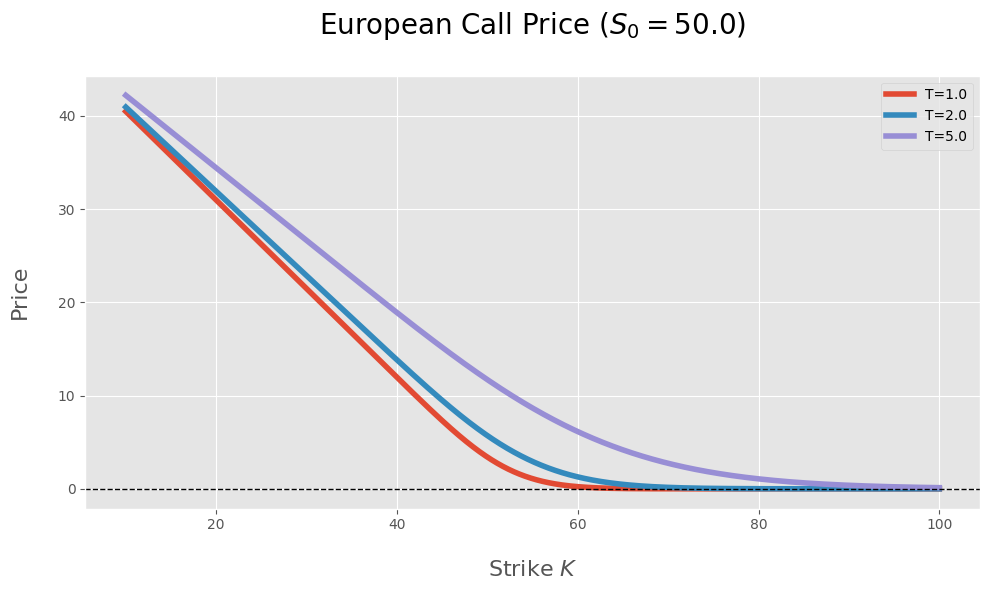

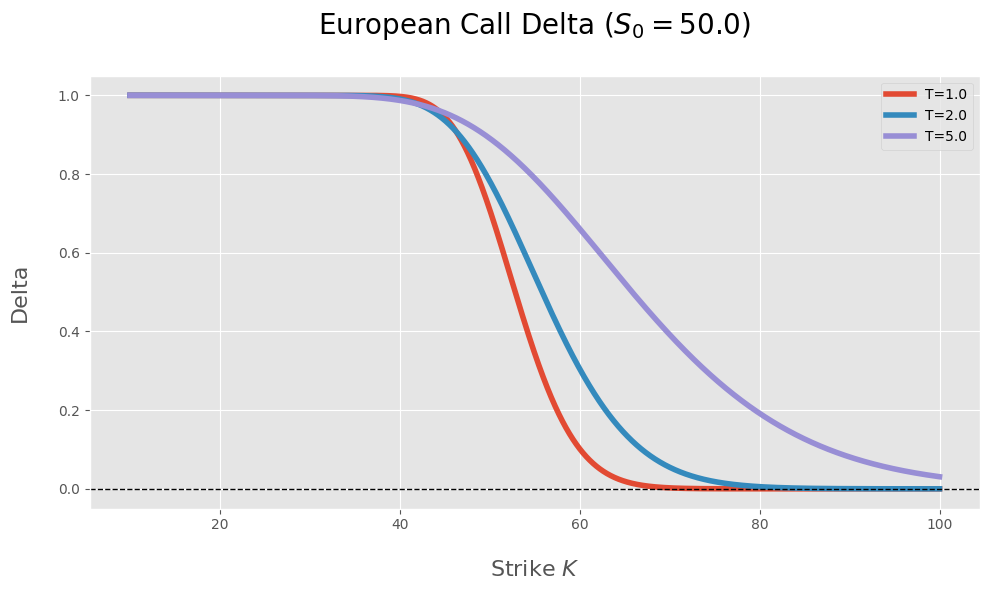

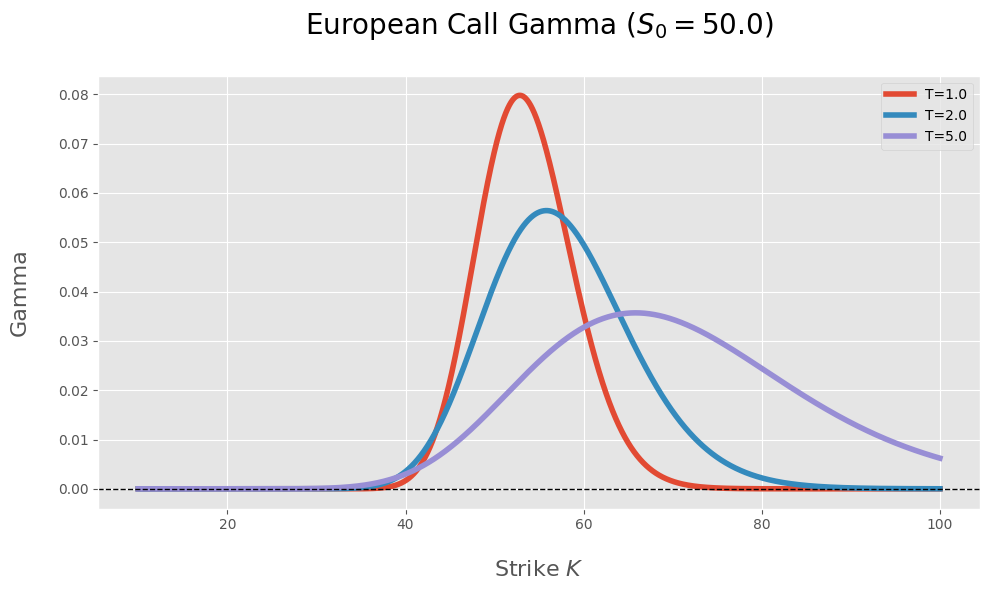

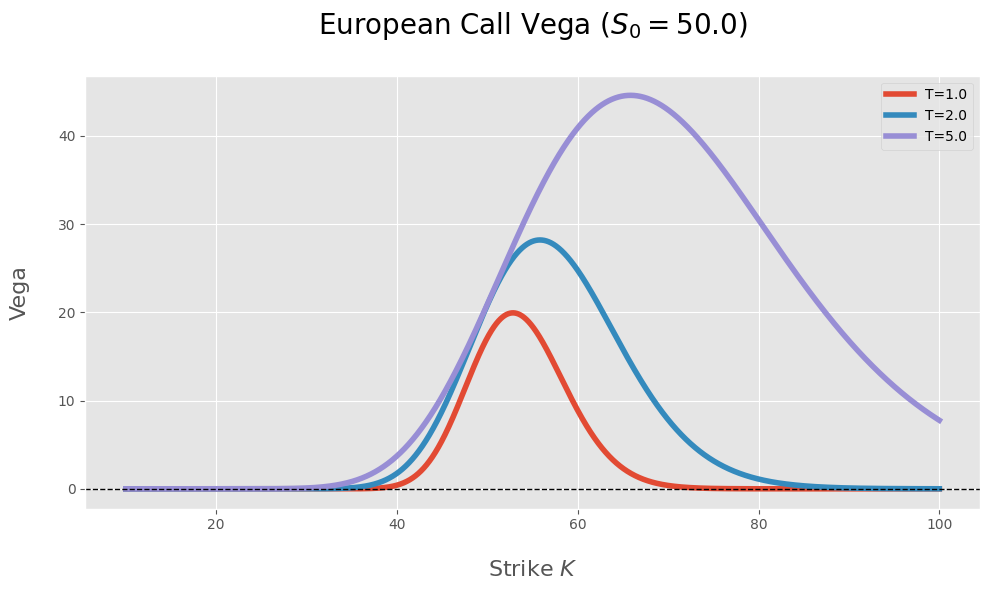

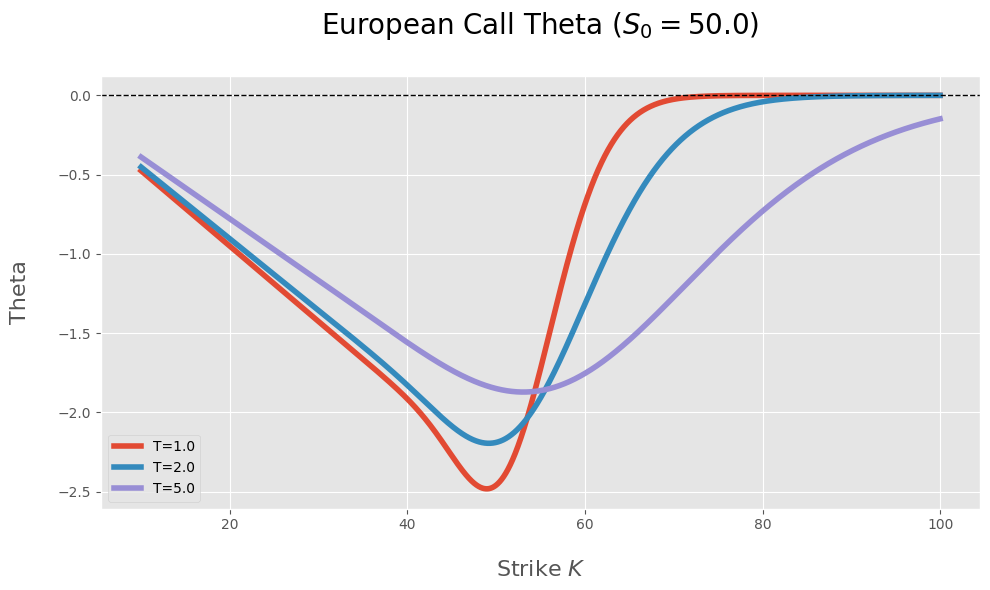

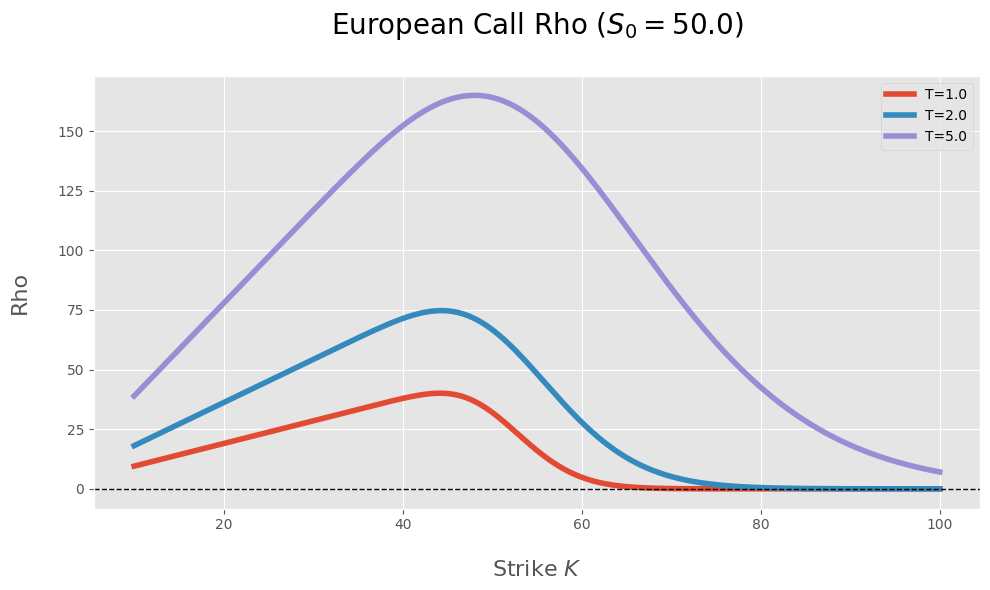

In [6]:
K_vec = np.arange(10, 100, 0.01)
T_vec = [1.0, 2.0, 5.0]
S0 = 50.0
output_list = ['Price', 'Delta', 'Gamma', 'Vega', 'Theta', 'Rho']

plot_data = {output: [] for output in output_list}
for output in output_list:
    for _T in T_vec:
        calculated_values = black_scholes_eur_call(r=0.05, T=_T, S0=S0, sigma=0.1, K=K_vec,
                                                   output=output)
        plot_data[output].append(calculated_values)

list(plot_data['Price'][0])
plotter_params = []
for output in output_list:
    param_bundle = []
    for i in range(len(T_vec)):
        T_bundle = list(plot_data[output][i])
        param_bundle.append(T_bundle)

    plotter_params.append((output, param_bundle))

for param, y_data in plotter_params:
    my_plotter(x=K_vec, y=y_data, names=[f'T={T_vec[0]}', f'T={T_vec[1]}', f'T={T_vec[2]}'],
               layout={'title': f'European Call {param} ($S_0={S0}$)',
                       'x_label': 'Strike $K$',
                       'y_label': f'{param}'})

## HW 2/3: BSM pricer for put options

In [7]:
"""The pricing function of European put option"""
def black_scholes_eur_put(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray],
                           output: str = 'price') -> np.ndarray:
    """
    Black-Scholes pricer of European put option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0
    assert T > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(-d1_vec)
    N_d2_vec = norm.cdf(-d2_vec)

    derN_d1 = norm.pdf(d1_vec)

    output = output.lower()
    if output == 'price':
        return K * np.exp((-1.0)*r*T) * N_d2_vec - S0 * N_d1_vec
    elif output == 'delta':
        return (-1.0) * N_d1_vec
    elif output == 'gamma':
        return derN_d1 / (S0 * sigma * T**0.5)
    elif output == 'vega':
        return S0 * derN_d1 * T**0.5
    elif output == 'theta':
        return (-S0 * derN_d1 * sigma / (2 * T**0.5)) + (r * K * np.exp((-1.0)*r*T) * N_d2_vec)
    elif output == 'rho':
        return -K * T * np.exp((-1.0)*r*T) * N_d2_vec
    else:
        raise ValueError(f"Invalid output type '{output}'."
                         "Choose from: 'price', 'delta', 'vega', 'theta', 'rho', 'gamma'.")

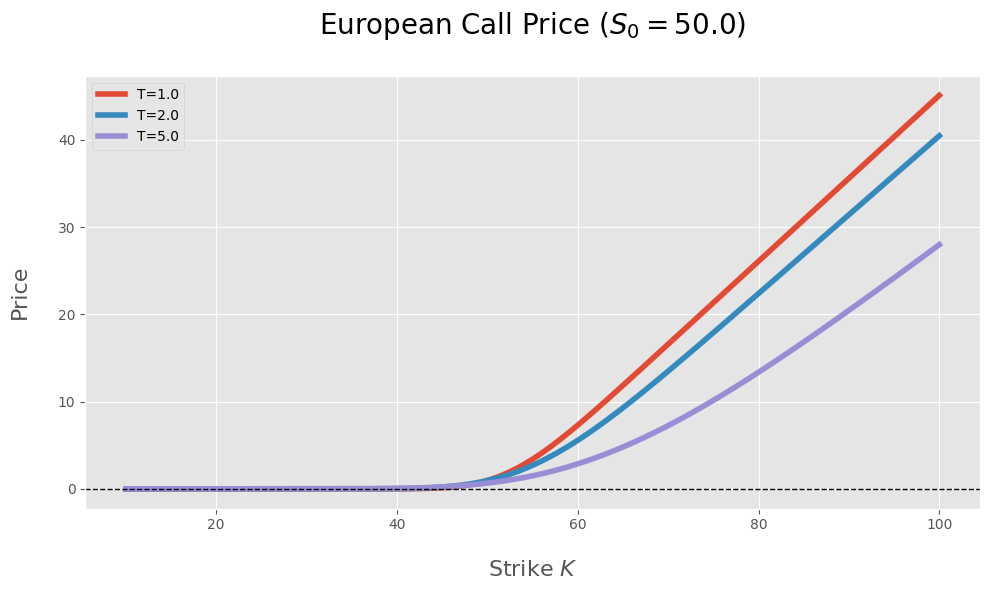

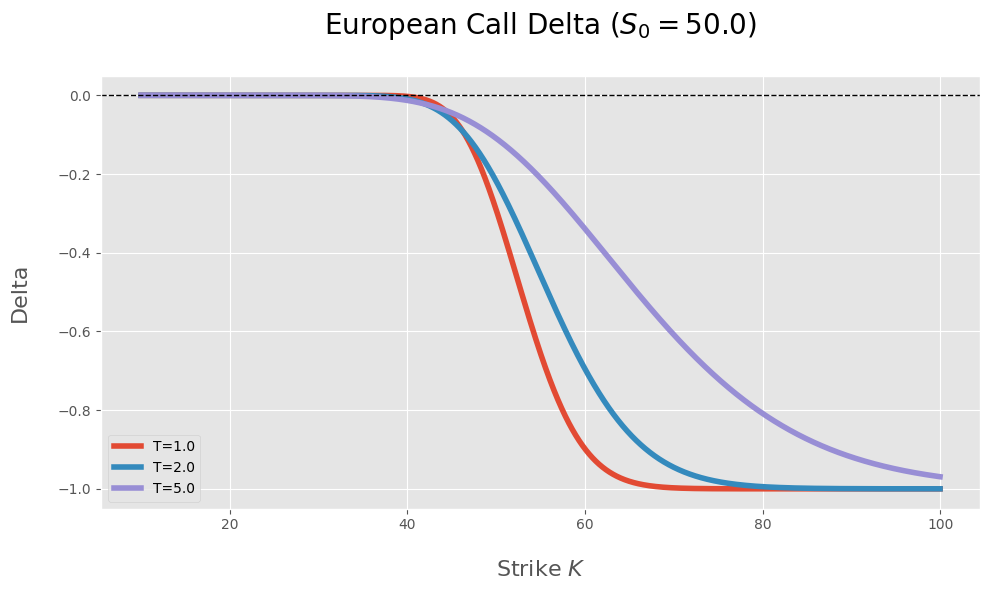

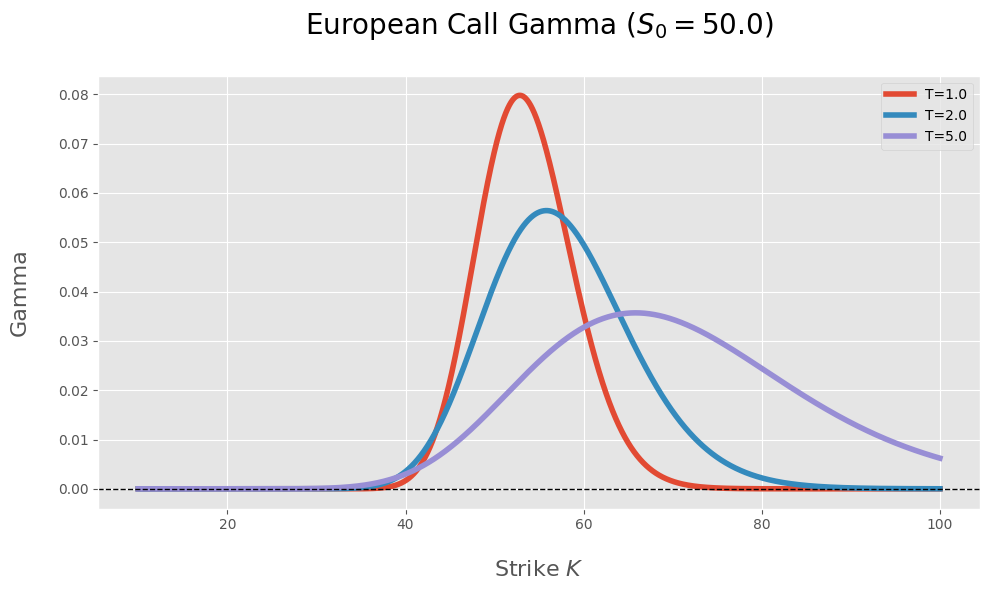

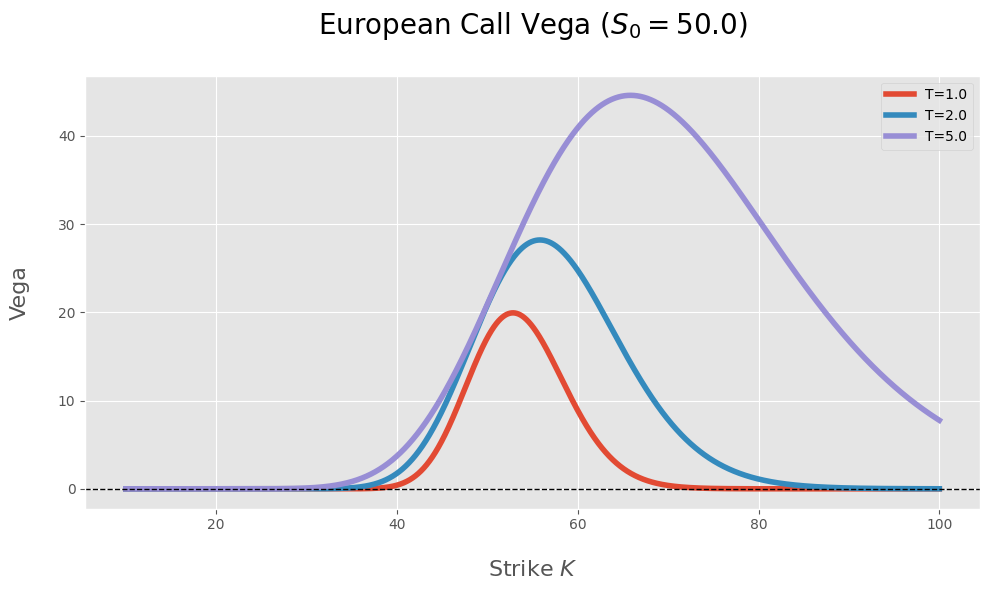

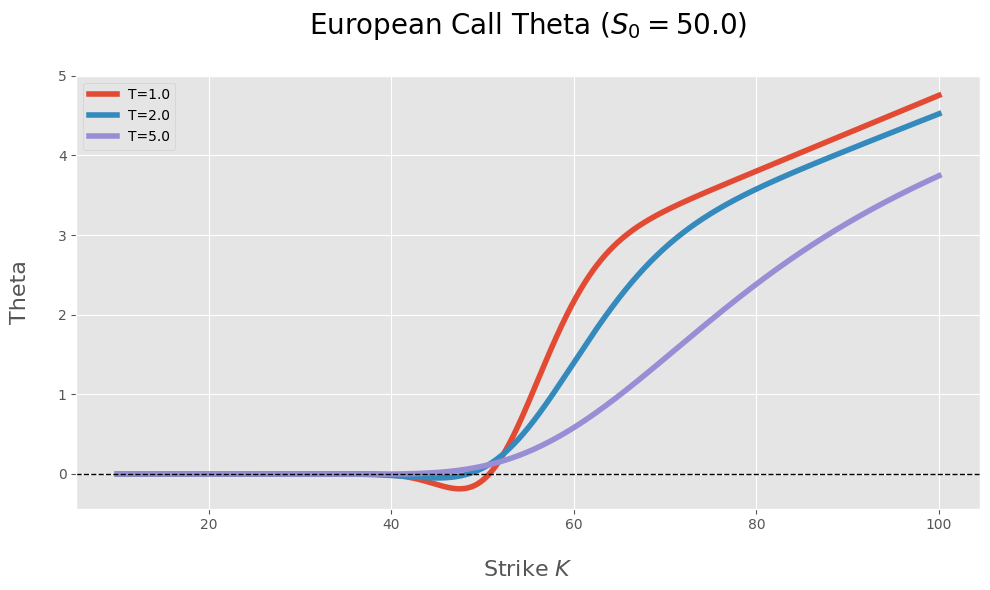

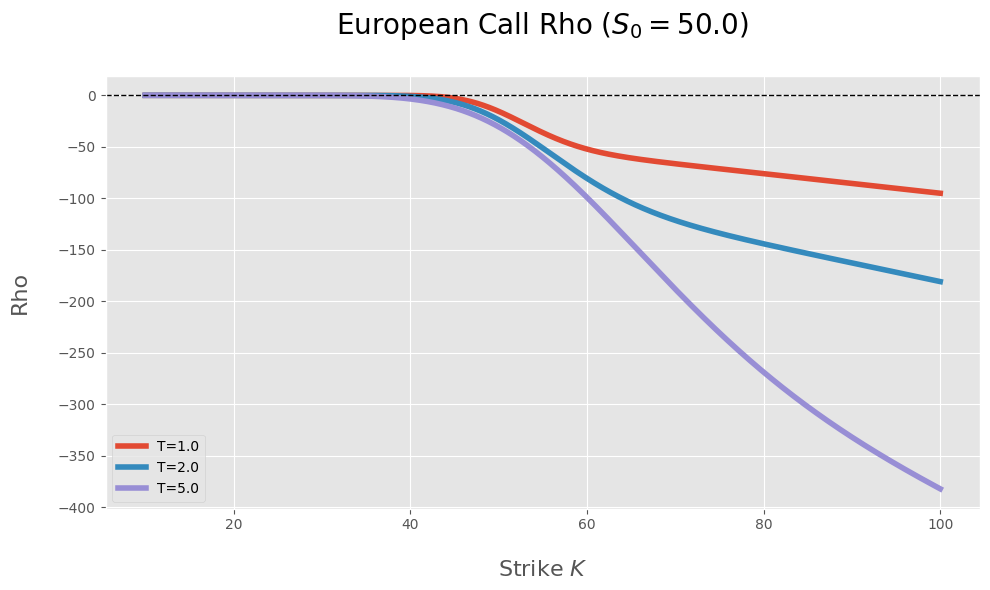

In [8]:
K_vec = np.arange(10, 100, 0.01)
T_vec = [1.0, 2.0, 5.0]
S0 = 50.0
output_list = ['Price', 'Delta', 'Gamma', 'Vega', 'Theta', 'Rho']

plot_data = {output: [] for output in output_list}
for output in output_list:
    for _T in T_vec:
        calculated_values = black_scholes_eur_put(r=0.05, T=_T, S0=S0, sigma=0.1, K=K_vec,
                                                   output=output)
        plot_data[output].append(calculated_values)

#list(plot_data['Price'][0])
plotter_params = []
for output in output_list:
    param_bundle = []
    for i in range(len(T_vec)):
        T_bundle = list(plot_data[output][i])
        param_bundle.append(T_bundle)

    plotter_params.append((output, param_bundle))

for param, y_data in plotter_params:
    my_plotter(x=K_vec, y=y_data, names=[f'T={T_vec[0]}', f'T={T_vec[1]}', f'T={T_vec[2]}'],
               layout={'title': f'European Call {param} ($S_0={S0}$)',
                       'x_label': 'Strike $K$',
                       'y_label': f'{param}'})

## HW 2/4: Put-Call parity check

Put-call parity holds.


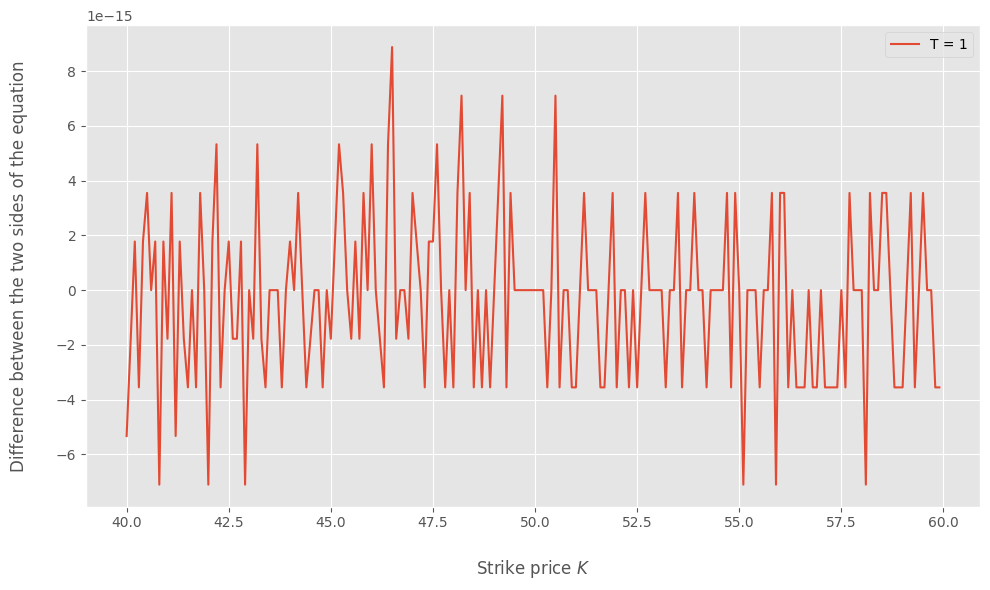

In [18]:
K_vec = np.arange(40, 60, 0.1)
T_vec = [1.0]
S0 = 50.0
r = 0.05

diff_to_plot= []
parity_holds= []
for _T in T_vec:
    call = black_scholes_eur_call(r=0.05, T=_T, S0=S0, sigma=0.3, K=K_vec, output='price')
    put = black_scholes_eur_put(r=0.05, T=_T, S0=S0, sigma=0.3, K=K_vec, output='price')
    left_side = call - put
    right_side = S0 - K_vec * np.exp((-1.0)*r*_T)
    diff_to_plot.append(left_side - right_side)
    parity_holds.append(np.isclose(left_side, right_side))

plt.figure(figsize=(10, 6))

for diffs, T in zip(diff_to_plot, T_vec):
    plt.plot(K_vec, diffs, label=f"T = {int(T)}")

if np.array(parity_holds).all():
    print('Put-call parity holds.')
else:
    print('Put-call parity doesn\'t hold.')

plt.xlabel('Strike price $K$')
plt.ylabel('Difference between the two sides of the equation')

plt.legend()
plt.style.use('ggplot')
plt.tight_layout()
plt.show()

Egyenlet két fele közötti eltérés elhanyagolható nagyságú (pl.: 4*10^-15), szóval vehetjük úgy, hogy a put-call paritás fenn áll.